In [3]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + identity
        out = self.relu(out)
        return out

In [4]:
block = ResidualBlock(64)
x = torch.randn(1, 64, 56, 56)
y = block(x)
print(x.shape, y.shape)

torch.Size([1, 64, 56, 56]) torch.Size([1, 64, 56, 56])


In [5]:
from torchvision.models import resnet50
model = resnet50(weights=None)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [6]:
model.layer1

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, t

In [7]:
model.layer1[0]

Bottleneck(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (downsample): Sequential(
    (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
)

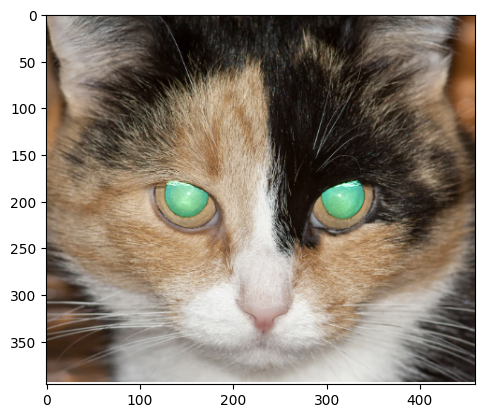

In [9]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

img = Image.open('cat.png').convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

image = transform(img)

plt.imshow(img)

In [10]:
print(image.shape)
print(image.unsqueeze(0).shape)

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


In [11]:
image = image.unsqueeze(0)

In [14]:
x = image
print("Input:", x.shape)

Input: torch.Size([1, 3, 224, 224])


In [16]:
model.layer1[0]

Bottleneck(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (downsample): Sequential(
    (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
)

In [25]:
def iterate_layer(model, x):
    x = model.conv1(x)
    print(f"After conv1 -> {x.shape}")
    x = model.bn1(x)
    print(f"After bn1 -> {x.shape}")
    x = model.relu(x)
    print(f"After relu -> {x.shape}")
    x = model.maxpool(x)
    print(f"After maxpool -> {x.shape}")
    out = model.layer1[0](x)
    print(f"After layer1 -> {out.shape}")

In [26]:
print(x.shape)
iterate_layer(model, x)

torch.Size([1, 3, 224, 224])
After conv1 -> torch.Size([1, 64, 112, 112])
After bn1 -> torch.Size([1, 64, 112, 112])
After relu -> torch.Size([1, 64, 112, 112])
After maxpool -> torch.Size([1, 64, 56, 56])
After layer1 -> torch.Size([1, 256, 56, 56])


Before layer1[0]: torch.Size([1, 64, 56, 56])
After layer1[0]: torch.Size([1, 256, 56, 56])


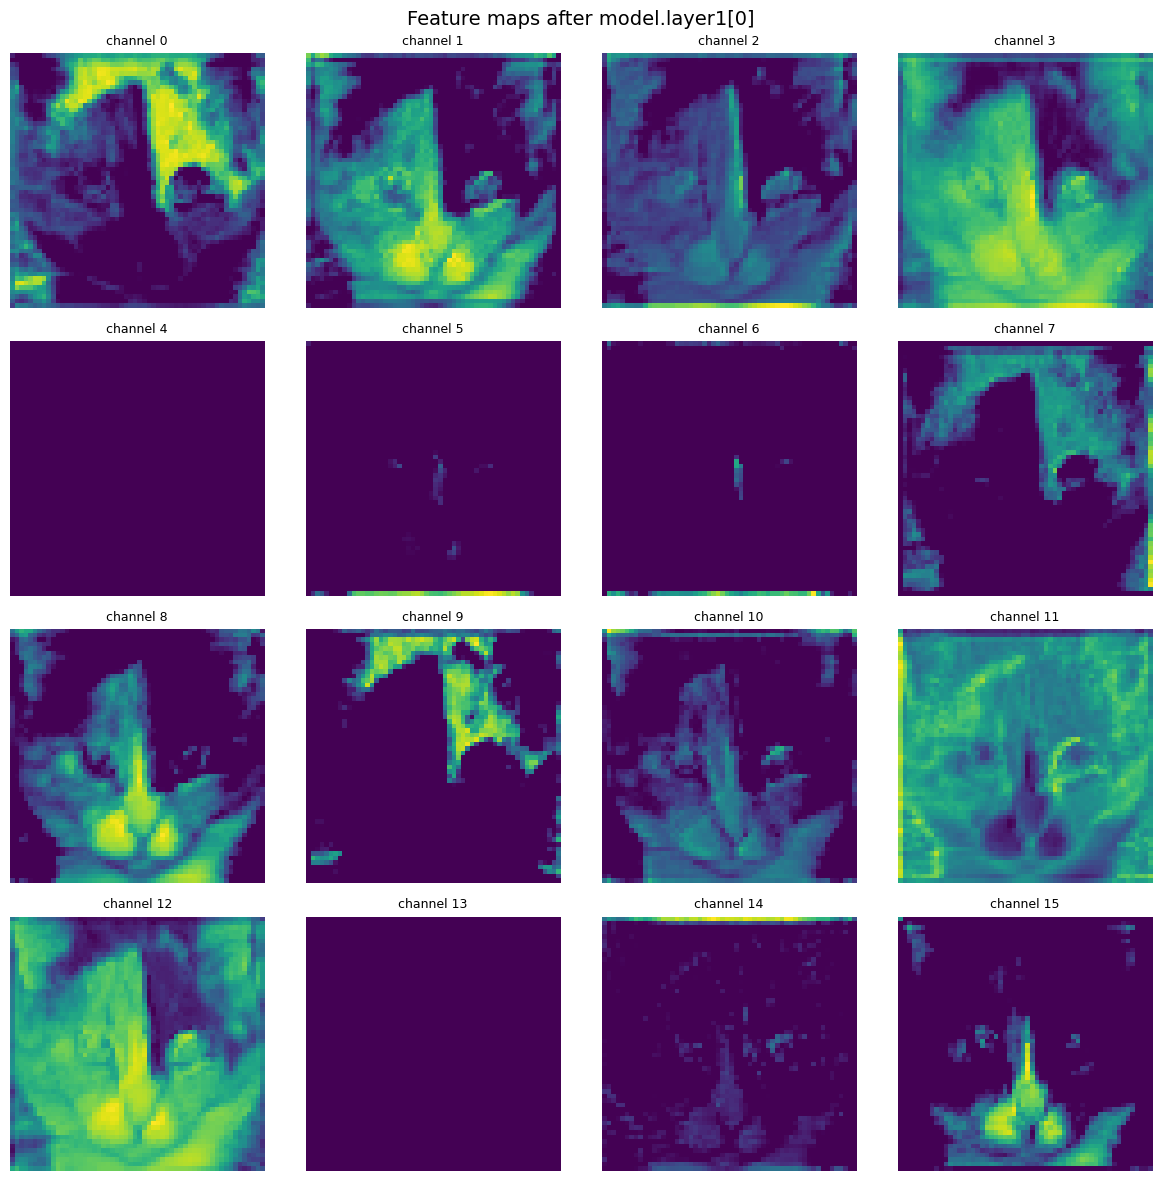

In [27]:
import matplotlib.pyplot as plt
model.eval()
with torch.no_grad():
    x = model.conv1(image)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)
    print("Before layer1[0]:", x.shape)

    out = model.layer1[0](x)
    print("After layer1[0]:", out.shape)

feature_maps = out.squeeze(0)
n_channels = 16
cols = 4
rows = n_channels // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    fmap = feature_maps[i].numpy()
    ax.imshow(fmap, cmap="viridis")
    ax.set_title(f"channel {i}", fontsize=9)
    ax.axis("off")

plt.suptitle("Feature maps after model.layer1[0]", fontsize=14)
plt.tight_layout()
plt.show()